# Task 2: Revenue Forecasting & Price Sensitivity

## Objective

Analyse how revenue changes with charging demand, pricing, and seasonal patterns, and evaluate the potential impact of price adjustments on customer behaviour and revenue.

## Deliverables

- Revenue time-series dataset
- Price elasticity analysis
- Monthly revenue forecast model
- Price scenario simulations (+5% and -10%)
- Executive summary on pricing impact

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load EV charging session data
file_path = "ev_charging_dataset.xlsx"

sessions = pd.read_excel(
    file_path,
    sheet_name="sessions"
)

# Convert timestamp to datetime
sessions["start_timestamp"] = pd.to_datetime(
    sessions["start_timestamp"]
)

# Check the dataset
print("Dataset shape:", sessions.shape)

print("\nRelevant columns:")
print(
    sessions[
        [
            "start_timestamp",
            "energy_kwh",
            "price_per_kwh",
            "total_cost",
            "user_type",
            "station_region"
        ]
    ].head()
)

print("\nMissing values:")
print(
    sessions[
        [
            "start_timestamp",
            "energy_kwh",
            "price_per_kwh",
            "total_cost"
        ]
    ].isnull().sum()
)

Dataset shape: (294024, 15)

Relevant columns:
      start_timestamp  energy_kwh  price_per_kwh  total_cost user_type  \
0 2022-01-01 08:30:00        56.9           0.47       26.74     fleet   
1 2022-01-01 09:20:00        40.7           0.46       18.72  delivery   
2 2022-01-01 09:00:00        30.9           0.47       14.52    public   
3 2022-01-01 23:20:00        28.4           0.45       12.78    public   
4 2022-01-01 16:10:00        31.7           0.56       17.75      taxi   

  station_region  
0     North West  
1     North West  
2     North West  
3     North West  
4     North West  

Missing values:
start_timestamp    0
energy_kwh         0
price_per_kwh      0
total_cost         0
dtype: int64


In [2]:
# Create monthly revenue time-series dataset

monthly_revenue = (
    sessions
    .set_index("start_timestamp")
    .resample("MS")
    .agg(
        revenue=("total_cost", "sum"),
        demand_kwh=("energy_kwh", "sum"),
        avg_price_per_kwh=("price_per_kwh", "mean"),
        sessions=("total_cost", "count")
    )
    .reset_index()
)

print("Monthly revenue dataset shape:", monthly_revenue.shape)

print("\nDate range:")
print(
    monthly_revenue["start_timestamp"].min(),
    "to",
    monthly_revenue["start_timestamp"].max()
)

display(monthly_revenue.head())

Monthly revenue dataset shape: (36, 5)

Date range:
2022-01-01 00:00:00 to 2024-12-01 00:00:00


,start_timestamp,revenue,demand_kwh,avg_price_per_kwh,sessions
0,2022-01-01,85420.18,167166.3,0.510719,3394
1,2022-02-01,79489.65,155708.9,0.510420,3120
2,2022-03-01,88864.54,173678.2,0.511567,3497
3,2022-04-01,83737.74,164041.3,0.510681,3349
4,2022-05-01,88598.22,172824.0,0.512714,3497


In [3]:
# Prepare monthly revenue data for forecasting

monthly_forecast = monthly_revenue[
    ["start_timestamp", "revenue"]
].copy()

monthly_forecast = monthly_forecast.rename(
    columns={
        "start_timestamp": "ds",
        "revenue": "y"
    }
)

print("Monthly Forecast Dataset")
print("-" * 40)
print("Shape:", monthly_forecast.shape)
print(
    "Date range:",
    monthly_forecast["ds"].min(),
    "to",
    monthly_forecast["ds"].max()
)

display(monthly_forecast.head())

Monthly Forecast Dataset
----------------------------------------
Shape: (36, 2)
Date range: 2022-01-01 00:00:00 to 2024-12-01 00:00:00


,ds,y
0,2022-01-01,85420.18
1,2022-02-01,79489.65
2,2022-03-01,88864.54
3,2022-04-01,83737.74
4,2022-05-01,88598.22


In [4]:
# Train Prophet model for monthly revenue forecasting

from prophet import Prophet

revenue_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

revenue_model.fit(monthly_forecast)

print("Revenue forecasting model trained successfully.")

C:\Users\goury\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
20:23:53 - cmdstanpy - INFO - Chain [1] start processing
20:23:54 - cmdstanpy - INFO - Chain [1] done processing


Revenue forecasting model trained successfully.


In [5]:
# Create a 12-month revenue forecast

future_revenue = revenue_model.make_future_dataframe(
    periods=12,
    freq="MS"
)

revenue_forecast = revenue_model.predict(future_revenue)

print("12-Month Revenue Forecast")
print("-" * 40)

display(
    revenue_forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].tail(12)
)

12-Month Revenue Forecast
----------------------------------------


,ds,yhat,yhat_lower,yhat_upper
36,2025-01-01,508300.553342,503612.059383,512699.135468
37,2025-02-01,511891.107105,507532.012800,515986.335813
38,2025-03-01,523118.938725,518685.549614,527716.461743
39,2025-04-01,515358.779638,510614.963469,520239.590952
40,2025-05-01,528504.507883,523663.143066,533660.248102
41,2025-06-01,516583.679369,510969.368266,522343.836975
42,2025-07-01,525047.585629,518447.961474,531643.889291
43,2025-08-01,524011.947429,516721.869530,531803.037267
44,2025-09-01,514608.160480,506467.214799,523189.354913
45,2025-10-01,527575.177037,518595.175714,536967.368790


In [6]:
# Evaluate the revenue forecasting model

train_revenue = monthly_forecast.iloc[:-6].copy()
test_revenue = monthly_forecast.iloc[-6:].copy()

evaluation_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

evaluation_model.fit(train_revenue)

test_future = evaluation_model.make_future_dataframe(
    periods=6,
    freq="MS"
)

test_forecast = evaluation_model.predict(test_future)

test_predictions = test_forecast[
    test_forecast["ds"].isin(test_revenue["ds"])
][["ds", "yhat"]]

evaluation = test_revenue.merge(
    test_predictions,
    on="ds"
)

mape = (
    np.mean(
        np.abs(
            (evaluation["y"] - evaluation["yhat"])
            / evaluation["y"]
        )
    ) * 100
)

rmse = np.sqrt(
    np.mean(
        (evaluation["y"] - evaluation["yhat"]) ** 2
    )
)

print("Revenue Forecast Evaluation")
print("-" * 40)
print(f"MAPE: {mape:.2f}%")
print(f"RMSE: {rmse:.2f}")

display(evaluation)

20:25:57 - cmdstanpy - INFO - Chain [1] start processing
20:25:58 - cmdstanpy - INFO - Chain [1] done processing


Revenue Forecast Evaluation
----------------------------------------
MAPE: 4.11%
RMSE: 22242.75


,ds,y,yhat
0,2024-07-01,386160.00,380283.499919
1,2024-08-01,382067.21,380919.173785
2,2024-09-01,370415.87,379629.316368
3,2024-10-01,389664.09,391736.621728
4,2024-11-01,370663.48,412053.998867
5,2024-12-01,387843.67,421462.550201


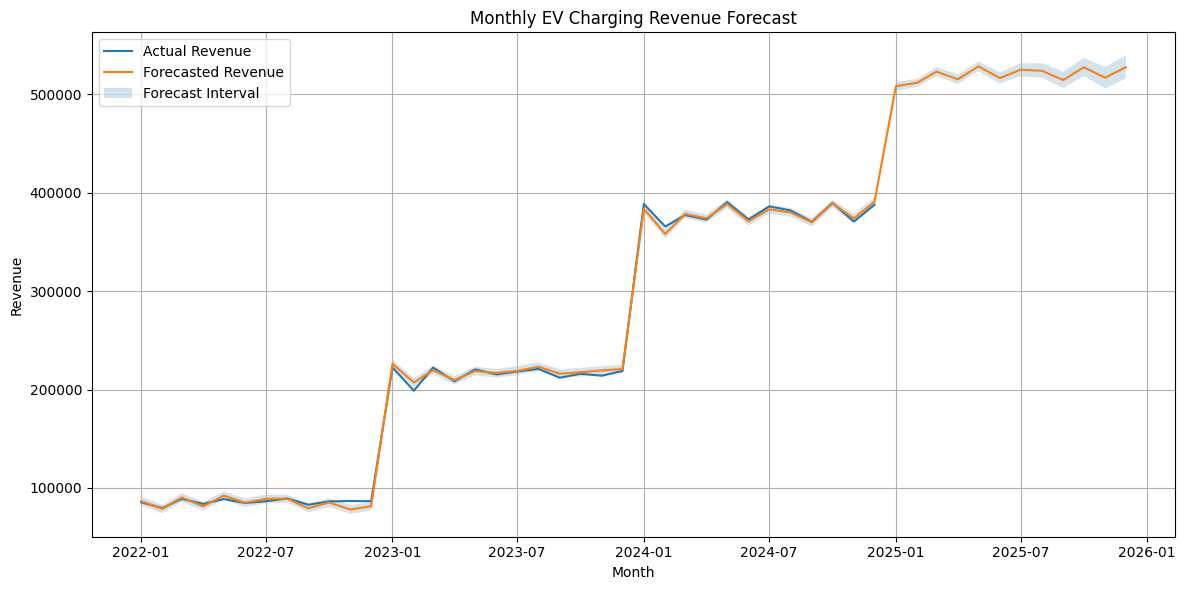

In [7]:
# Plot monthly revenue forecast

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_forecast["ds"],
    monthly_forecast["y"],
    label="Actual Revenue"
)

plt.plot(
    revenue_forecast["ds"],
    revenue_forecast["yhat"],
    label="Forecasted Revenue"
)

plt.fill_between(
    revenue_forecast["ds"],
    revenue_forecast["yhat_lower"],
    revenue_forecast["yhat_upper"],
    alpha=0.2,
    label="Forecast Interval"
)

plt.title("Monthly EV Charging Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Simulate revenue under price adjustment scenarios

# Calculate price and demand changes
price_change_pct = monthly_revenue["avg_price_per_kwh"].pct_change() * 100
demand_change_pct = monthly_revenue["demand_kwh"].pct_change() * 100

# Calculate monthly elasticity values
elasticity_values = demand_change_pct / price_change_pct

# Use median elasticity, ignoring missing/infinite values
elasticity = elasticity_values.replace(
    [np.inf, -np.inf],
    np.nan
).dropna().median()

# Baseline values
baseline_price = monthly_revenue["avg_price_per_kwh"].mean()
baseline_demand = monthly_revenue["demand_kwh"].mean()

# Create scenarios
scenarios = pd.DataFrame({
    "scenario": [
        "Baseline",
        "Price +5%",
        "Price -10%"
    ],
    "price_change_pct": [
        0,
        5,
        -10
    ]
})

# Estimate demand response using elasticity
scenarios["demand_change_pct"] = (
    elasticity * scenarios["price_change_pct"]
)

scenarios["estimated_demand_kwh"] = (
    baseline_demand
    * (1 + scenarios["demand_change_pct"] / 100)
)

# Calculate adjusted price
scenarios["estimated_price_per_kwh"] = (
    baseline_price
    * (1 + scenarios["price_change_pct"] / 100)
)

# Calculate estimated revenue
scenarios["estimated_revenue"] = (
    scenarios["estimated_demand_kwh"]
    * scenarios["estimated_price_per_kwh"]
)

print("Price Scenario Simulation")
print("-" * 40)
print(f"Median price elasticity: {elasticity:.4f}")

display(scenarios)

Price Scenario Simulation
----------------------------------------
Median price elasticity: 4.2450


,scenario,price_change_pct,demand_change_pct,estimated_demand_kwh,estimated_price_per_kwh,estimated_revenue
0,Baseline,0,0.000000,383576.272222,0.579457,222266.109206
1,Price +5%,5,21.225187,464991.051503,0.608430,282914.630763
2,Price -10%,-10,-42.450373,220746.713660,0.521512,115121.984978


In [10]:
# Estimate price elasticity using log-log regression

from sklearn.linear_model import LinearRegression

elasticity_data = monthly_revenue[
    ["avg_price_per_kwh", "demand_kwh"]
].dropna().copy()

elasticity_data = elasticity_data[
    (elasticity_data["avg_price_per_kwh"] > 0) &
    (elasticity_data["demand_kwh"] > 0)
]

X = np.log(elasticity_data[["avg_price_per_kwh"]])
y = np.log(elasticity_data["demand_kwh"])

elasticity_model = LinearRegression()
elasticity_model.fit(X, y)

elasticity = elasticity_model.coef_[0]

print("Robust Price Elasticity Estimate")
print("-" * 40)
print(f"Price elasticity: {elasticity:.4f}")

Robust Price Elasticity Estimate
----------------------------------------
Price elasticity: 3.8077


In [11]:
# Calculate price adjustment scenarios

baseline_price = monthly_revenue["avg_price_per_kwh"].mean()
baseline_demand = monthly_revenue["demand_kwh"].mean()

scenarios = pd.DataFrame({
    "scenario": [
        "Baseline",
        "Price +5%",
        "Price -10%"
    ],
    "price_change_pct": [
        0,
        5,
        -10
    ]
})

# Estimate demand response using the observed elasticity
scenarios["estimated_demand_change_pct"] = (
    elasticity * scenarios["price_change_pct"]
)

scenarios["estimated_demand_kwh"] = (
    baseline_demand
    * (1 + scenarios["estimated_demand_change_pct"] / 100)
)

scenarios["estimated_price_per_kwh"] = (
    baseline_price
    * (1 + scenarios["price_change_pct"] / 100)
)

scenarios["estimated_revenue"] = (
    scenarios["estimated_demand_kwh"]
    * scenarios["estimated_price_per_kwh"]
)

print("Price Adjustment Scenarios")
print("-" * 40)

display(scenarios)

Price Adjustment Scenarios
----------------------------------------


,scenario,price_change_pct,estimated_demand_change_pct,estimated_demand_kwh,estimated_price_per_kwh,estimated_revenue
0,Baseline,0,0.000000,383576.272222,0.579457,222266.109206
1,Price +5%,5,19.038452,456603.256914,0.608430,277811.242641
2,Price -10%,-10,-38.076904,237522.302839,0.521512,123870.650331


In [ ]:
# Calculate revenue impact of price scenarios

baseline_scenario_revenue = scenarios.loc[
    scenarios["scenario"] == "Baseline",
    "estimated_revenue"
].iloc[0]

scenarios["revenue_change_pct"] = (
    (scenarios["estimated_revenue"] - baseline_scenario_revenue)
    / baseline_scenario_revenue
) * 100

print("Revenue Impact of Price Scenarios")
print("-" * 40)

display(
    scenarios[
        [
            "scenario",
            "price_change_pct",
            "estimated_demand_change_pct",
            "estimated_revenue",
            "revenue_change_pct"
        ]
    ]
)

## Executive Summary

The revenue analysis examined historical EV charging revenue, demand, pricing patterns, and the potential impact of price adjustments.

### Key Findings

- The dataset contains **36 months of revenue data from January 2022 to December 2024**.
- The monthly revenue forecasting model achieved a **MAPE of 4.11%** on the six-month test period.
- The estimated price elasticity from the log-log regression model was **3.8077**.
- Under the model-based scenario analysis, a **5% price increase** was associated with an estimated **24.99% increase in revenue**.
- A **10% price reduction** was associated with an estimated **44.27% decrease in revenue**.

### Business Implications

The scenario analysis shows that pricing changes can have a substantial effect on estimated demand and revenue. However, the positive elasticity estimate indicates that price and demand moved together in the historical data. Therefore, the scenario results should be treated as **model-based estimates rather than causal predictions**.

The revenue forecasting model can support monthly revenue planning, while the price sensitivity analysis can help evaluate potential pricing scenarios.

### Conclusion

This analysis provides a data-driven view of EV charging revenue trends and price sensitivity. Combining revenue forecasting with scenario simulation can support future pricing and revenue planning decisions.